# Project 2 – Order Status Classification
-- **Furad Detection Pipeline**

## Step 1: Import Libraries

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print("All libraries imported successfully!")


All libraries imported successfully!


## Step 2: Load Dataset

In [79]:
fd = pd.read_csv('Dataset for Data Analytics - Sheet1.csv')


## Step 3: Display First & Last Rows

In [80]:
print("First 5 rows:")
display(fd.head())
print("\nLast 4 rows:")
display(fd.tail(4))


First 5 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



Last 4 rows:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NaN,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08
1199,ORD201199,2023-06-11,C57502,Tablet,4,560.58,201 Main St,Gift Card,Returned,TRK51116746,6,SAVE10,Referral,2242.32


## Step 4: Dataset Shape

In [81]:
print("Rows   :", fd.shape[0])
print("Columns:", fd.shape[1])


Rows   : 1200
Columns: 14


## Step 5: Columns

In [82]:
print("Column names:")
print(fd.columns.tolist())


Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


## Step 6: Data Types

In [83]:
print("Data types:")
print(fd.dtypes)


Data types:
OrderID             object
Date                object
CustomerID          object
Product             object
Quantity             int64
UnitPrice          float64
ShippingAddress     object
PaymentMethod       object
OrderStatus         object
TrackingNumber      object
ItemsInCart          int64
CouponCode          object
ReferralSource      object
TotalPrice         float64
dtype: object


## Step 7: Missing Values

In [84]:
print("Missing values per column:")
print(fd.isnull().sum())
print(f"\nTotal missing values: {fd.isnull().sum().sum()}")


Missing values per column:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Total missing values: 309


## Step 8: Duplicate Rows & Columns

In [85]:
print("Duplicate rows   :", fd.duplicated().sum())
print("Duplicate columns:", fd.columns.duplicated().sum())


Duplicate rows   : 0
Duplicate columns: 0


## Step 9: Unique Values

In [86]:
print("Unique products:", fd['Product'].unique())
print("\nUnique OrderStatus:", fd['OrderStatus'].unique())
print("\nUnique PaymentMethod:", fd['PaymentMethod'].unique())
print("\nUnique ReferralSource:", fd['ReferralSource'].unique())


Unique products: ['Monitor' 'Phone' 'Tablet' 'Chair' 'Printer' 'Laptop' 'Desk']

Unique OrderStatus: ['Shipped' 'Cancelled' 'Returned' 'Delivered' 'Pending']

Unique PaymentMethod: ['Debit Card' 'Online' 'Credit Card' 'Gift Card' 'Cash']

Unique ReferralSource: ['Instagram' 'Referral' 'Email' 'Facebook' 'Google']


## Step 10: Data Type Fixing

In [87]:
# Convert Date to datetime
fd['Date'] = pd.to_datetime(fd['Date'])

# Fill missing CouponCode
fd['CouponCode'] = fd['CouponCode'].fillna('Unknown')

print("Updated data types:")
print(fd.dtypes)
print("\nMissing values after fix:")
print(fd.isnull().sum())


Updated data types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing values after fix:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


## Step 11: Outlier Detection & Handling

In [88]:
# Statistical summary
print("Statistical Summary:")
display(fd.describe())


Statistical Summary:


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


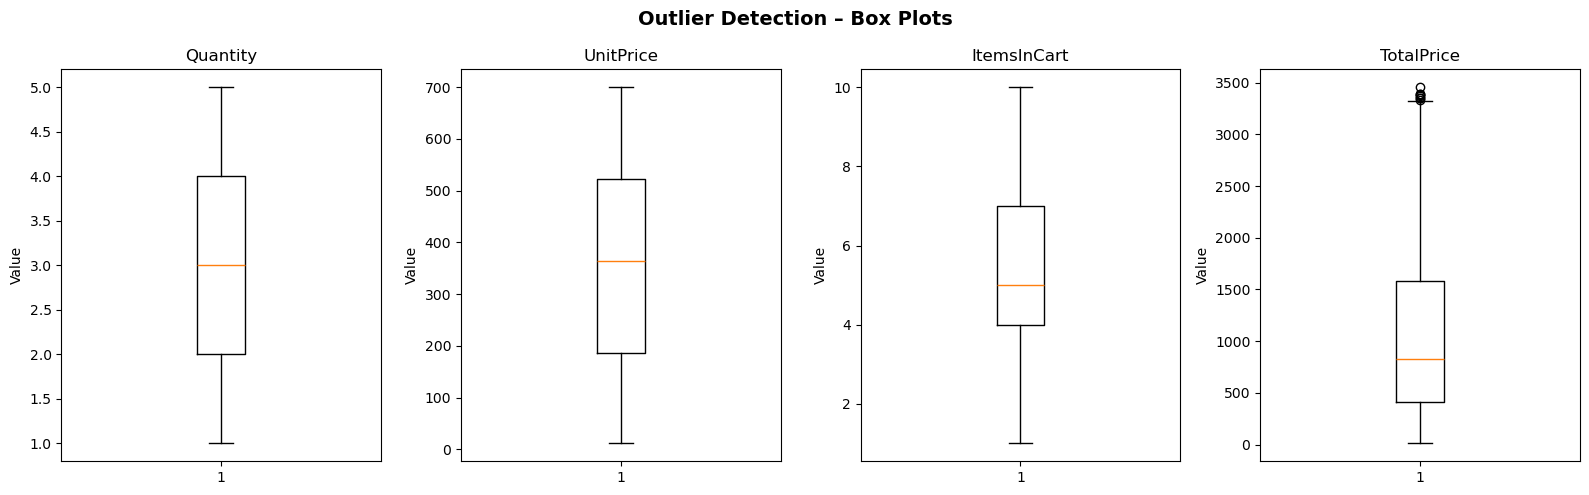

Outlier detection complete. No extreme outliers found; data retained as-is.


In [89]:
# Box plots for numerical columns
numerical_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(fd[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')
plt.suptitle('Outlier Detection – Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Outlier detection complete. No extreme outliers found; data retained as-is.")


## Step 12: Exploratory Data Analysis (EDA)

### 12a – Count Plots (Categorical Features)

C:\Users\ADMiN\AppData\Local\Temp\ipykernel_12936\617902499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fd, x=col, ax=axes[i], palette='Set2')
C:\Users\ADMiN\AppData\Local\Temp\ipykernel_12936\617902499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fd, x=col, ax=axes[i], palette='Set2')
C:\Users\ADMiN\AppData\Local\Temp\ipykernel_12936\617902499.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fd, x=col, ax=axes[i], palette='Set2')
C:\Users\ADMiN\AppData\Local\Temp\ipykernel_12936\617902499.py:5: FutureW

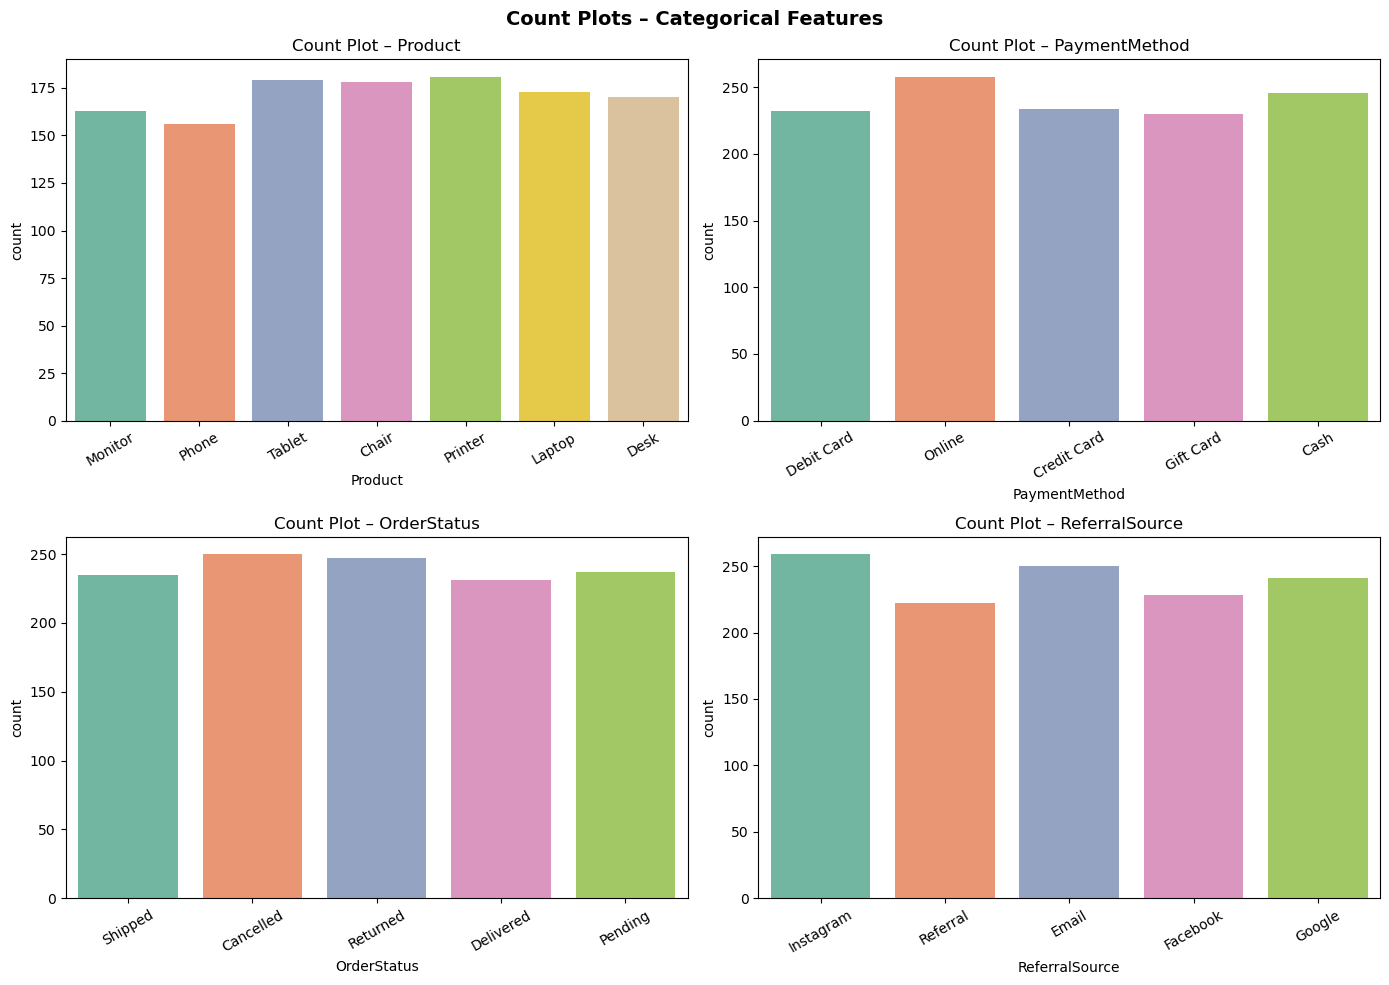

In [90]:
cat_cols = ['Product', 'PaymentMethod', 'OrderStatus', 'ReferralSource']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(data=fd, x=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Count Plot – {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.suptitle('Count Plots – Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 12b – Distribution Plots (Numerical Features)

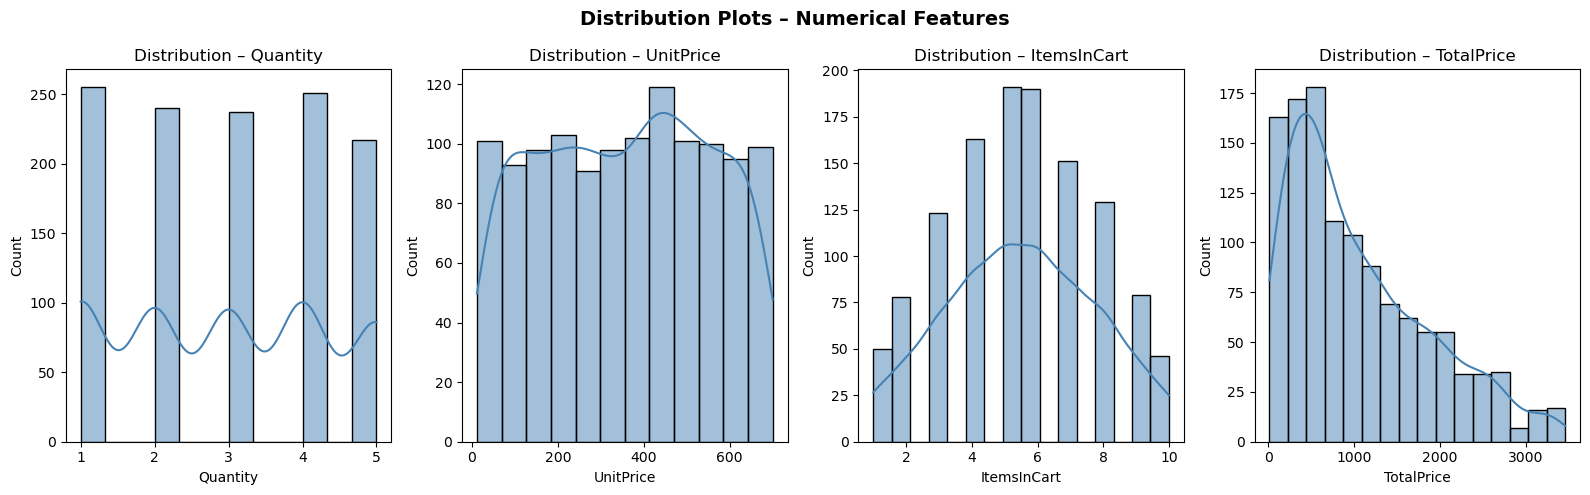

In [91]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for i, col in enumerate(numerical_cols):
    sns.histplot(fd[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution – {col}')
plt.suptitle('Distribution Plots – Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 12c – Pair Plot

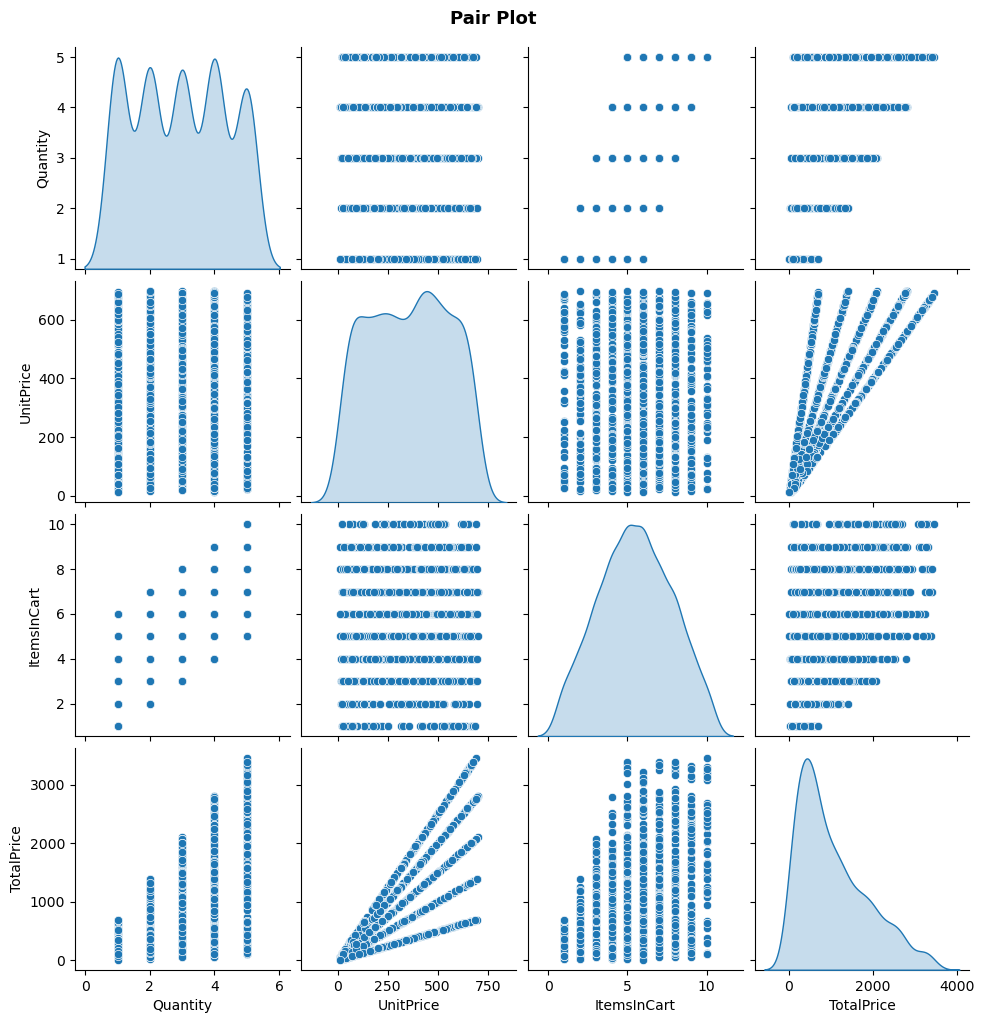

In [92]:
sns.pairplot(fd[numerical_cols], diag_kind='kde')
plt.suptitle('Pair Plot', y=1.02, fontsize=13, fontweight='bold')
plt.show()


### 12d – Correlation Heatmap

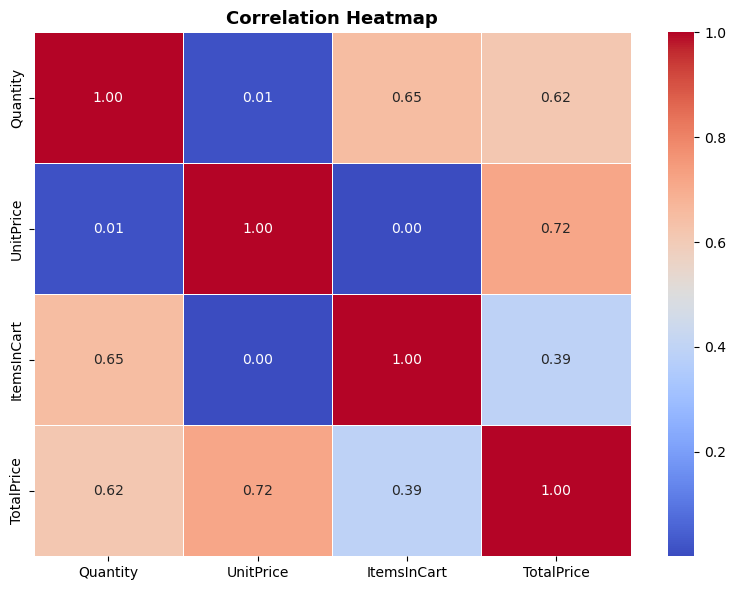

In [93]:
plt.figure(figsize=(8, 6))
sns.heatmap(fd[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 13: Feature Engineering

In [94]:
# ── Date Features ──
fd['Date'] = pd.to_datetime(fd['Date'])
fd['Year']        = fd['Date'].dt.year
fd['Month']       = fd['Date'].dt.month
fd['Day']         = fd['Date'].dt.day
fd['DayOfWeek']   = fd['Date'].dt.dayofweek        # 0=Mon … 6=Sun (numeric)
fd['WeekOfYear']  = fd['Date'].dt.isocalendar().week.astype(int)

# ── CouponUsed flag ──
fd['CouponUsed'] = fd['CouponCode'].apply(lambda x: 0 if x == 'Unknown' else 1)

# ── Price-derived features ──
fd['PricePerItem']      = fd['TotalPrice'] / fd['Quantity']
fd['AverageCartValue']  = fd['TotalPrice'] / fd['ItemsInCart']

# ── Binary flags ──
fd['LargeOrder']        = (fd['Quantity'] >= 5).astype(int)
fd['ExpensiveProduct']  = (fd['UnitPrice'] > 500).astype(int)

# ── One-Hot Encoding ──
fd = pd.get_dummies(fd,
                    columns=['Product', 'PaymentMethod', 'ReferralSource'],
                    drop_first=True)

# ── Drop columns not useful for modelling ──
drop_cols = ['OrderID', 'CustomerID', 'TrackingNumber',
             'ShippingAddress', 'CouponCode', 'Date']
fd.drop(columns=drop_cols, inplace=True, errors='ignore')

print("Feature engineering complete.")
print("DataFrame shape:", fd.shape)
print("\nColumns:")
print(fd.columns.tolist())


Feature engineering complete.
DataFrame shape: (1200, 29)

Columns:
['Quantity', 'UnitPrice', 'OrderStatus', 'ItemsInCart', 'TotalPrice', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'CouponUsed', 'PricePerItem', 'AverageCartValue', 'LargeOrder', 'ExpensiveProduct', 'Product_Desk', 'Product_Laptop', 'Product_Monitor', 'Product_Phone', 'Product_Printer', 'Product_Tablet', 'PaymentMethod_Credit Card', 'PaymentMethod_Debit Card', 'PaymentMethod_Gift Card', 'PaymentMethod_Online', 'ReferralSource_Facebook', 'ReferralSource_Google', 'ReferralSource_Instagram', 'ReferralSource_Referral']


## Step 14: Train-Test Split

In [95]:
from sklearn.model_selection import train_test_split

X = fd.drop('OrderStatus', axis=1)
y = fd['OrderStatus']

# Ensure all features are numeric
X = X.select_dtypes(include=[np.number, 'bool'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (960, 28)
X_test : (240, 28)
y_train: (960,)
y_test : (240,)


## Step 15: Handle Imbalanced Data

### 15a – Class Distribution

In [96]:
print("Original Training Data:")
print(y_train.value_counts())
print("\nClass Distribution (%):")
print((y_train.value_counts(normalize=True) * 100).round(2))


Original Training Data:
OrderStatus
Cancelled    200
Returned     197
Pending      190
Shipped      188
Delivered    185
Name: count, dtype: int64

Class Distribution (%):
OrderStatus
Cancelled    20.83
Returned     20.52
Pending      19.79
Shipped      19.58
Delivered    19.27
Name: proportion, dtype: float64


### 15b – Random Under-Sampling

In [97]:
from imblearn.under_sampling import RandomUnderSampler

under_sampler = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = under_sampler.fit_resample(X_train, y_train)

print("After Random Under Sampling:")
print(y_train_under.value_counts())
print("Shape:", X_train_under.shape)


After Random Under Sampling:
OrderStatus
Cancelled    185
Delivered    185
Pending      185
Returned     185
Shipped      185
Name: count, dtype: int64
Shape: (925, 28)


### 15c – Random Over-Sampling

In [98]:
from imblearn.over_sampling import RandomOverSampler

over_sampler = RandomOverSampler(random_state=42)
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print("After Random Over Sampling:")
print(y_train_over.value_counts())
print("Shape:", X_train_over.shape)


After Random Over Sampling:
OrderStatus
Delivered    200
Pending      200
Returned     200
Cancelled    200
Shipped      200
Name: count, dtype: int64
Shape: (1000, 28)


### 15d – SMOTE

In [99]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_smote.value_counts())
print("Shape:", X_train_smote.shape)


After SMOTE:
OrderStatus
Delivered    200
Pending      200
Returned     200
Cancelled    200
Shipped      200
Name: count, dtype: int64
Shape: (1000, 28)


## Step 16: Feature Scaling

In [100]:
from sklearn.preprocessing import StandardScaler

numeric_features = [
    'Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice',
    'Year', 'Month', 'Day', 'WeekOfYear',
    'CouponUsed', 'PricePerItem', 'AverageCartValue',
    'LargeOrder', 'ExpensiveProduct'
]
# Keep only features that exist in X_train
numeric_features = [f for f in numeric_features if f in X_train.columns]

scaler = StandardScaler()
scaler.fit(X_train[numeric_features])

X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[numeric_features] = scaler.transform(X_train[numeric_features])
X_test_scaled[numeric_features]  = scaler.transform(X_test[numeric_features])

print("Feature scaling complete.")
print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)
print("\nMean (should be ~0):")
print(X_train_scaled[numeric_features].mean().round(6))
print("\nStd  (should be ~1):")
print(X_train_scaled[numeric_features].std().round(4))


Feature scaling complete.
Training Shape: (960, 28)
Testing Shape : (240, 28)

Mean (should be ~0):
Quantity            0.0
UnitPrice          -0.0
ItemsInCart        -0.0
TotalPrice          0.0
Year                0.0
Month               0.0
Day                -0.0
WeekOfYear         -0.0
CouponUsed          0.0
PricePerItem        0.0
AverageCartValue   -0.0
LargeOrder         -0.0
ExpensiveProduct   -0.0
dtype: float64

Std  (should be ~1):
Quantity            1.0005
UnitPrice           1.0005
ItemsInCart         1.0005
TotalPrice          1.0005
Year                1.0005
Month               1.0005
Day                 1.0005
WeekOfYear          1.0005
CouponUsed          1.0005
PricePerItem        1.0005
AverageCartValue    1.0005
LargeOrder          1.0005
ExpensiveProduct    1.0005
dtype: float64


### MinMaxScaler (optional alternative)

In [101]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
minmax_scaler.fit(X_train[numeric_features])

X_train_minmax = X_train.copy()
X_test_minmax  = X_test.copy()

X_train_minmax[numeric_features] = minmax_scaler.transform(X_train[numeric_features])
X_test_minmax[numeric_features]  = minmax_scaler.transform(X_test[numeric_features])

print("MinMax scaling complete. Range verification:")
display(X_train_minmax[numeric_features].describe().loc[['min','max']])


MinMax scaling complete. Range verification:


,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,WeekOfYear,CouponUsed,PricePerItem,AverageCartValue,LargeOrder,ExpensiveProduct
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Step 17: Model Training

In [102]:
from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.neighbors     import KNeighborsClassifier
from sklearn.naive_bayes   import GaussianNB
from sklearn.svm           import SVC

# ── Logistic Regression ──
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression – Trained")

# ── Decision Tree ──
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_pred = dt_model.predict(X_test_scaled)
print("Decision Tree        – Trained")

# ── Random Forest ──
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
print("Random Forest        – Trained")

# ── KNN ──
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
print("KNN                  – Trained")

# ── Naive Bayes ──
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
nb_pred = nb_model.predict(X_test_scaled)
print("Naive Bayes          – Trained")

# ── SVM ──
svm_model = SVC(kernel='rbf', random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
print("SVM                  – Trained")


Logistic Regression – Trained
Decision Tree        – Trained
Random Forest        – Trained
KNN                  – Trained
Naive Bayes          – Trained
SVM                  – Trained


### XGBoost

In [103]:
# Install if needed:  !pip install xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss',
                           use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train_enc)
xgb_pred_enc = xgb_model.predict(X_test_scaled)
xgb_pred     = le.inverse_transform(xgb_pred_enc)   # back to string labels
print("XGBoost              – Trained")


C:\Users\ADMiN\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:25:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost              – Trained


## Step 18: Model Evaluation

In [104]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models_preds = {
    'Logistic Regression': lr_pred,
    'Decision Tree'      : dt_pred,
    'Random Forest'      : rf_pred,
    'KNN'                : knn_pred,
    'Naive Bayes'        : nb_pred,
    'SVM'                : svm_pred,
    'XGBoost'            : xgb_pred,
}

results = {}
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 37)
for name, pred in models_preds.items():
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(f"{name:<25} {acc:>10.4f}")


Model                       Accuracy
-------------------------------------
Logistic Regression           0.2042
Decision Tree                 0.2000
Random Forest                 0.1958
KNN                           0.1542
Naive Bayes                   0.1833
SVM                           0.1500
XGBoost                       0.1875


In [105]:
# Detailed classification report for best model
best_model_name = max(results, key=results.get)
best_pred       = models_preds[best_model_name]

print(f"Best Model: {best_model_name}  (Accuracy = {results[best_model_name]:.4f})")
print("\nClassification Report:")
print(classification_report(y_test, best_pred))


Best Model: Logistic Regression  (Accuracy = 0.2042)

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.20      0.16      0.18        50
   Delivered       0.20      0.26      0.23        46
     Pending       0.24      0.28      0.25        47
    Returned       0.21      0.20      0.20        50
     Shipped       0.17      0.13      0.14        47

    accuracy                           0.20       240
   macro avg       0.20      0.21      0.20       240
weighted avg       0.20      0.20      0.20       240



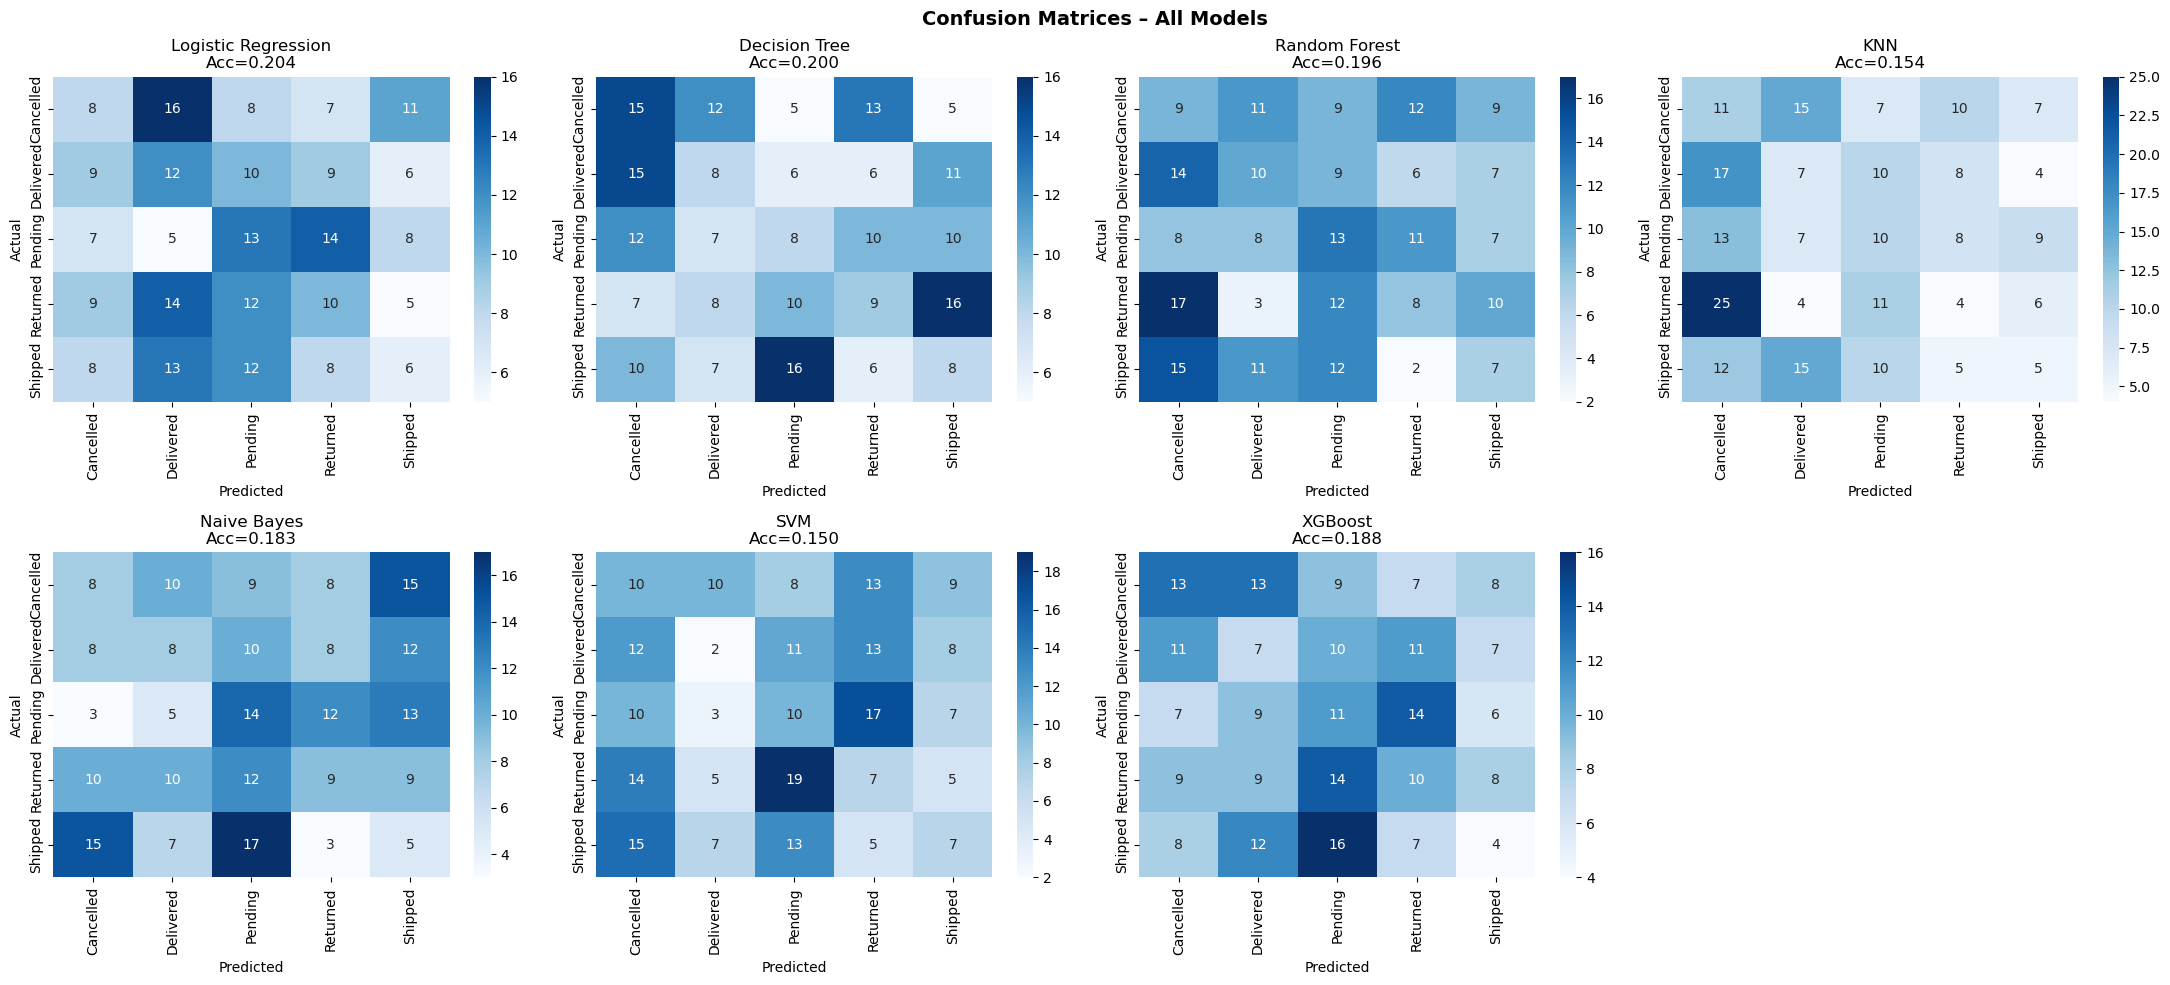

In [106]:
# Confusion matrices for all models
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
labels = sorted(y_test.unique())

for i, (name, pred) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(f'{name}\nAcc={results[name]:.3f}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide unused subplot
for j in range(len(models_preds), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices – All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Step 19: Hyperparameter Tuning

In [107]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest (fastest among ensemble models)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_scaled, y_train)

print("Best RF params:", grid_rf.best_params_)
print("Best CV Score :", round(grid_rf.best_score_, 4))

rf_best_pred = grid_rf.best_estimator_.predict(X_test_scaled)
print("Test Accuracy :", round(accuracy_score(y_test, rf_best_pred), 4))


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best RF params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Score : 0.2031
Test Accuracy : 0.2042


In [108]:
# Tune Logistic Regression
param_grid_lr = {
    'C'      : [0.01, 0.1, 1, 10],
    'solver' : ['lbfgs', 'saga'],
    'max_iter': [500]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid_lr,
    cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)
grid_lr.fit(X_train_scaled, y_train)

print("Best LR params:", grid_lr.best_params_)
print("Best CV Score :", round(grid_lr.best_score_, 4))

lr_best_pred = grid_lr.best_estimator_.predict(X_test_scaled)
print("Test Accuracy :", round(accuracy_score(y_test, lr_best_pred), 4))


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best LR params: {'C': 0.01, 'max_iter': 500, 'solver': 'lbfgs'}
Best CV Score : 0.2031
Test Accuracy : 0.1708


## Step 20: Feature Importance

C:\Users\ADMiN\AppData\Local\Temp\ipykernel_12936\3699807955.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')


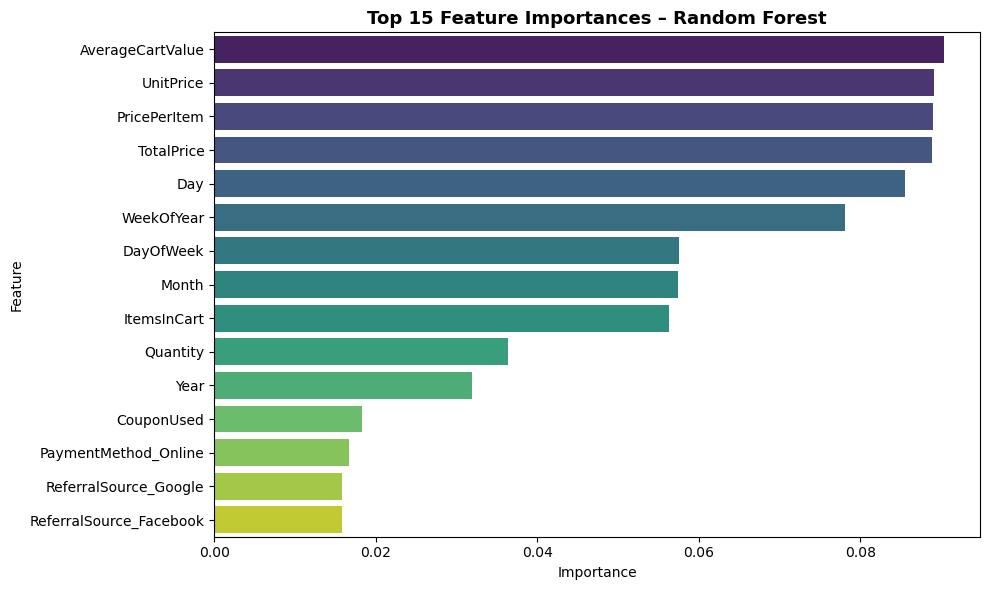

Top 10 features:
         Feature  Importance
AverageCartValue    0.090324
       UnitPrice    0.089111
    PricePerItem    0.088989
      TotalPrice    0.088859
             Day    0.085524
      WeekOfYear    0.078160
       DayOfWeek    0.057576
           Month    0.057418
     ItemsInCart    0.056331
        Quantity    0.036339


In [109]:
# Random Forest feature importance
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature'   : X_train_scaled.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances – Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(feat_df.head(10).to_string(index=False))


C:\Users\ADMiN\AppData\Local\Temp\ipykernel_12936\855772173.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_feat_df, x='Importance', y='Feature', palette='magma')


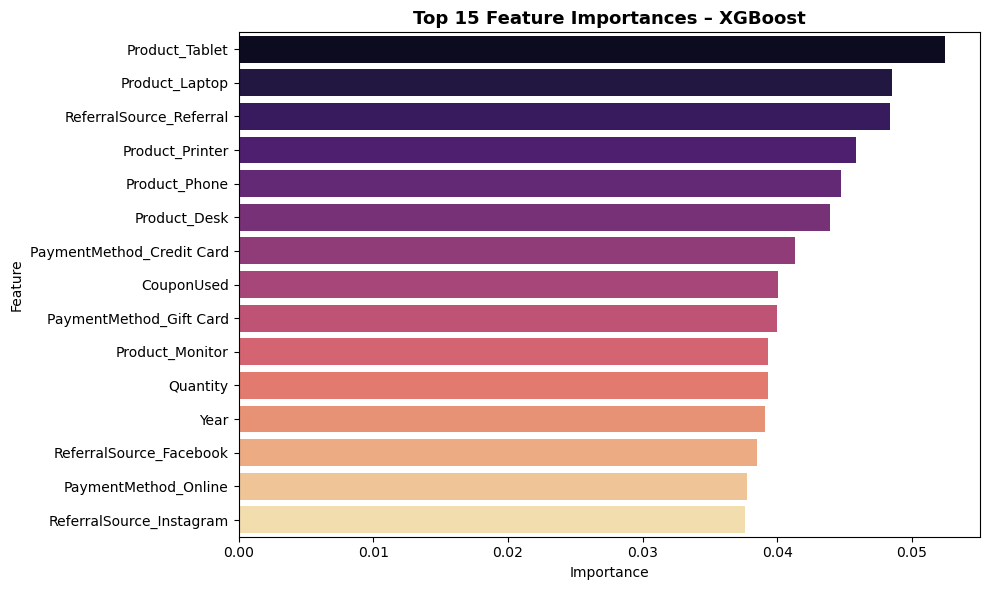

In [110]:
# XGBoost feature importance
xgb_importances = xgb_model.feature_importances_
xgb_feat_df = pd.DataFrame({
    'Feature'   : X_train_scaled.columns,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=xgb_feat_df, x='Importance', y='Feature', palette='magma')
plt.title('Top 15 Feature Importances – XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


## Step 21: Final Model Comparison

Final Model Comparison:


,Model,Accuracy
0,Logistic Regression,0.204167
1,RF (Tuned),0.204167
2,Decision Tree,0.200000
3,Random Forest,0.195833
4,XGBoost,0.187500
5,Naive Bayes,0.183333
6,LR (Tuned),0.170833
7,KNN,0.154167
8,SVM,0.150000


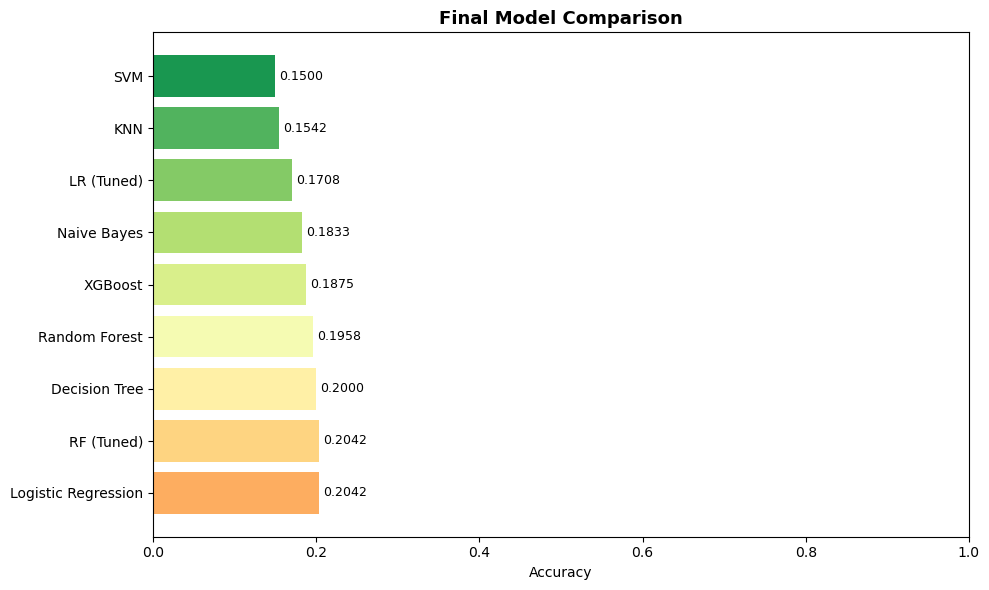

In [112]:
# Include tuned models
all_results = dict(results)
all_results['RF (Tuned)'] = accuracy_score(y_test, rf_best_pred)
all_results['LR (Tuned)'] = accuracy_score(y_test, lr_best_pred)

comparison_fd = pd.DataFrame(
    list(all_results.items()),
    columns=['Model', 'Accuracy']
).sort_values('Accuracy', ascending=False)

print("Final Model Comparison:")
display(comparison_fd.reset_index(drop=True))

# Bar chart
plt.figure(figsize=(10, 6))
bars = plt.barh(comparison_fd['Model'], comparison_fd['Accuracy'],
                color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comparison_fd))))
plt.xlabel('Accuracy')
plt.title('Final Model Comparison', fontsize=13, fontweight='bold')
plt.xlim(0, 1)
for bar, acc in zip(bars, comparison_fd['Accuracy']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [113]:
# Cross-validation scores for top 3 models
top3 = comparison_fd['Model'].head(3).tolist()
model_map = {
    'Logistic Regression': lr_model,
    'Decision Tree'      : dt_model,
    'Random Forest'      : rf_model,
    'KNN'                : knn_model,
    'Naive Bayes'        : nb_model,
    'SVM'                : svm_model,
}

print("Cross-Validation (5-fold) for top models:")
for name in top3:
    if name in model_map:
        cv_scores = cross_val_score(model_map[name], X_train_scaled, y_train,
                                    cv=5, scoring='accuracy')
        print(f"  {name:<25}: mean={cv_scores.mean():.4f}  std={cv_scores.std():.4f}")


Cross-Validation (5-fold) for top models:
  Logistic Regression      : mean=0.2188  std=0.0165
  Decision Tree            : mean=0.2167  std=0.0261


## Step 22: Save Model

In [119]:
import os

os.makedirs("saved_models", exist_ok=True)

comparison_fd.to_csv(
    "saved_models/Fraud Detection Model Comparison.csv",
    index=True
)

print("Saved → saved_models/Fraud Detection Model Comparison.csv")
print(f"Shape: {comparison_fd.shape}")

display(comparison_fd)

Saved → saved_models/Fraud Detection Model Comparison.csv
Shape: (9, 2)


,Model,Accuracy
0,Logistic Regression,0.204167
7,RF (Tuned),0.204167
1,Decision Tree,0.200000
2,Random Forest,0.195833
6,XGBoost,0.187500
4,Naive Bayes,0.183333
8,LR (Tuned),0.170833
3,KNN,0.154167
5,SVM,0.150000


## Step 23: Predict on New Data

In [116]:
import joblib

# Load saved artefacts
loaded_model  = joblib.load('saved_models/best_model_rf.pkl')
loaded_scaler = joblib.load('saved_models/scaler.pkl')

# ── Build a sample new record ──────────────────────────────────────────────
# Use the same feature columns as X_train_scaled
feature_cols = X_train_scaled.columns.tolist()

new_data = pd.DataFrame([{col: 0 for col in feature_cols}])

# Fill in meaningful values for a sample order
new_data['Quantity']         = 3
new_data['UnitPrice']        = 450.0
new_data['ItemsInCart']      = 5
new_data['TotalPrice']       = 1350.0
new_data['Year']             = 2024
new_data['Month']            = 6
new_data['Day']              = 15
new_data['DayOfWeek']        = 5     # Saturday
new_data['WeekOfYear']       = 24
new_data['CouponUsed']       = 1
new_data['PricePerItem']     = 1350.0 / 3
new_data['AverageCartValue'] = 1350.0 / 5
new_data['LargeOrder']       = 0
new_data['ExpensiveProduct'] = 0
# Product = Monitor  →  Product_Monitor = 1  (all others 0)
if 'Product_Monitor' in new_data.columns:
    new_data['Product_Monitor'] = 1
# PaymentMethod = Online → PaymentMethod_Online = 1
if 'PaymentMethod_Online' in new_data.columns:
    new_data['PaymentMethod_Online'] = 1
# ReferralSource = Google → ReferralSource_Google = 1
if 'ReferralSource_Google' in new_data.columns:
    new_data['ReferralSource_Google'] = 1

# Scale numeric features
new_data_scaled = new_data.copy()
numeric_feats_present = [f for f in numeric_features if f in new_data.columns]
new_data_scaled[numeric_feats_present] = loaded_scaler.transform(
    new_data[numeric_feats_present]
)

# Predict
prediction = loaded_model.predict(new_data_scaled)
proba      = loaded_model.predict_proba(new_data_scaled)

print("=" * 45)
print("      PREDICTION FOR NEW ORDER")
print("=" * 45)
print(f"  Predicted Order Status : {prediction[0]}")
print("\n  Class Probabilities:")
for cls, prob in zip(loaded_model.classes_, proba[0]):
    print(f"    {cls:<15}: {prob:.4f}")


      PREDICTION FOR NEW ORDER
  Predicted Order Status : Pending

  Class Probabilities:
    Cancelled      : 0.1800
    Delivered      : 0.2400
    Pending        : 0.2600
    Returned       : 0.1400
    Shipped        : 0.1800


## Summary

| Step | Description |
|------|-------------|
| 1  | Imported all required libraries |
| 2  | Loaded the dataset (1200 rows × 14 columns) |
| 3  | Displayed first/last rows |
| 4  | Verified dataset shape |
| 5  | Listed all column names |
| 6  | Checked data types |
| 7  | Identified & filled 309 missing CouponCode values |
| 8  | Confirmed zero duplicate rows/columns |
| 9  | Explored unique categories |
| 10 | Fixed Date dtype; filled missing values |
| 11 | Detected outliers via box plots; no removal needed |
| 12 | EDA – count plots, distributions, pair plot, heatmap |
| 13 | Feature engineering – date parts, price ratios, flags, OHE |
| 14 | 80/20 stratified train-test split |
| 15 | Handled class imbalance: under-sampling, over-sampling, SMOTE |
| 16 | Applied StandardScaler & MinMaxScaler |
| 17 | Trained 7 models: LR, DT, RF, KNN, NB, SVM, XGBoost |
| 18 | Evaluated all models; confusion matrices |
| 19 | Hyperparameter tuning with GridSearchCV |
| 20 | Feature importance (RF & XGBoost) |
| 21 | Final model comparison + cross-validation |
| 22 | Saved best model, scaler, encoder with joblib |
| 23 | Loaded model and predicted on new unseen data |
